In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import torch
import glob
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import os
import torch.nn as nn
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
import random
import numpy as np
import torch


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 尽量让 CUDA 计算确定
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

In [3]:
class Cifar10Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        :param root_dir: 包含所有图片的目录路径
        :param transform: 对图片进行的预处理操作
        """
        self.root_dir = root_dir
        self.transform = transform
        # 获取该目录下所有的 jpg 图片路径
        # self.image_paths = glob.glob(os.path.join(root_dir, "*.jpg"))
        # print(len(self.image_paths))
        folder_paths = [
            name
            for name in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, name))
        ]
        folder_paths.sort()
        self.image_list = []
        self.label_list = []
        count = 0
        for folder in folder_paths:
            folder_path = root_dir + "/" + folder
            # print(folder)
            data_=glob.glob(os.path.join(folder_path, "*.png"))
            self.image_list.extend(data_)
            self.label_list.extend([count]* len(data_))
            count+=1

    def __len__(self):
        # 返回数据集的总大小
        return len(self.image_list)

    def __getitem__(self, idx):
        # 1. 根据索引获取图片路径
        img_path = self.image_list[idx]

        # 2. 读取图片并确保是RGB格式
        image = Image.open(img_path).convert("RGB")
        label = self.label_list[idx]

        # 4. 应用转换 (例如转为 Tensor, 改变大小等)
        if self.transform:
            image = self.transform(image)

        return image, label



In [4]:
from torch.utils.data import Subset

g = torch.Generator()
g.manual_seed(42)

train_transform = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465],
            std=[0.2470, 0.2435, 0.2616],
        ),
        transforms.RandomErasing(p=0.20),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465],
            std=[0.2470, 0.2435, 0.2616],
        ),
    ]
)

test_path = "../../../../../data/cifar-10/test"
test_dataset = Cifar10Dataset(root_dir=test_path, transform=test_transform)
train_path = "../../../../../data/cifar-10/train"
train_dataset = Cifar10Dataset(root_dir=train_path, transform=train_transform)


batch_size = 256
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True, generator=g
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=False, generator=g
)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class WideBasicBlock(nn.Module):
    """
    WideResNet basic block for CIFAR-10.

    Structure:
        BN -> ReLU -> Conv
        BN -> ReLU -> Dropout -> Conv
        + shortcut

    This is closer to pre-activation ResNet / WideResNet style.
    """

    def __init__(self, in_channels, out_channels, stride=1, drop_rate=0.0):
        super().__init__()

        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )

        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=drop_rate) if drop_rate > 0 else nn.Identity()
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=stride,
                padding=0,
                bias=False,
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)

        out = self.bn1(x)
        out = self.relu1(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu2(out)
        out = self.dropout(out)
        out = self.conv2(out)

        out = out + residual
        return out


class WideResNet(nn.Module):
    """
    CIFAR-style WideResNet.

    depth should satisfy:
        depth = 6n + 4

    Examples:
        WRN-16-4: depth=16, widen_factor=4
        WRN-28-4: depth=28, widen_factor=4
        WRN-28-10: depth=28, widen_factor=10
    """

    def __init__(self, depth=28, widen_factor=4, drop_rate=0.2, num_classes=10):
        super().__init__()

        assert (depth - 4) % 6 == 0, "depth should be 6n + 4"
        n = (depth - 4) // 6

        channels = [
            16,
            16 * widen_factor,
            32 * widen_factor,
            64 * widen_factor,
        ]

        self.conv1 = nn.Conv2d(
            3,
            channels[0],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )

        self.stage1 = self._make_stage(
            in_channels=channels[0],
            out_channels=channels[1],
            num_blocks=n,
            stride=1,
            drop_rate=drop_rate,
        )

        self.stage2 = self._make_stage(
            in_channels=channels[1],
            out_channels=channels[2],
            num_blocks=n,
            stride=2,
            drop_rate=drop_rate,
        )

        self.stage3 = self._make_stage(
            in_channels=channels[2],
            out_channels=channels[3],
            num_blocks=n,
            stride=2,
            drop_rate=drop_rate,
        )

        self.bn = nn.BatchNorm2d(channels[3])
        self.relu = nn.ReLU(inplace=True)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels[3], num_classes)

        self._init_weights()

    def _make_stage(self, in_channels, out_channels, num_blocks, stride, drop_rate):
        layers = []

        layers.append(
            WideBasicBlock(
                in_channels=in_channels,
                out_channels=out_channels,
                stride=stride,
                drop_rate=drop_rate,
            )
        )

        for _ in range(1, num_blocks):
            layers.append(
                WideBasicBlock(
                    in_channels=out_channels,
                    out_channels=out_channels,
                    stride=1,
                    drop_rate=drop_rate,
                )
            )

        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu",
                )
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.conv1(x)  # [B, 16, 32, 32]

        x = self.stage1(x)  # [B, 16*k, 32, 32]
        x = self.stage2(x)  # [B, 32*k, 16, 16]
        x = self.stage3(x)  # [B, 64*k, 8, 8]

        x = self.bn(x)
        x = self.relu(x)

        x = self.avgpool(x)  # [B, 64*k, 1, 1]
        x = torch.flatten(x, 1)
        x = self.fc(x)  # [B, 10]

        return x

In [6]:
model = WideResNet(
    depth=28,
    widen_factor=4,
    drop_rate=0.2,
    num_classes=10,
).to(device)
print(model)
num_epochs=200
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.SGD(
    model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4, nesterov=True
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)
# print(model)

WideResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (stage1): Sequential(
    (0): WideBasicBlock(
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (dropout): Dropout(p=0.2, inplace=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (shortcut): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    )
    (1): WideBasicBlock(
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


In [7]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for step, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device).long()

        # forward
        logits = model(x)
        loss = criterion(logits, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计 loss
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size

        # 统计 accuracy
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += batch_size
        # if step % 20 == 0:
        #     print(f"Step [{step}/{len(train_loader)}], Training Loss: {loss.item():.4f}")

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device).long()

            logits = model(x)
            loss = criterion(logits, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size

            preds = logits.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [8]:


train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_test_acc = 0.0
epoch = 0

In [ ]:

for _ in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    scheduler.step()
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "cifar-10.pt")

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} |"
        f"LR: {current_lr:.6f}"
    )
    epoch+=1

Epoch [1/200] Train Loss: 1.6805, Train Acc: 0.4077 | Test Loss: 1.4676, Test Acc: 0.5350 |LR: 0.099994
Epoch [2/200] Train Loss: 1.2365, Train Acc: 0.6149 | Test Loss: 1.2215, Test Acc: 0.6300 |LR: 0.099975
Epoch [3/200] Train Loss: 1.0712, Train Acc: 0.6867 | Test Loss: 1.4645, Test Acc: 0.6213 |LR: 0.099945
Epoch [4/200] Train Loss: 0.9552, Train Acc: 0.7338 | Test Loss: 0.9868, Test Acc: 0.7257 |LR: 0.099901
Epoch [5/200] Train Loss: 0.8835, Train Acc: 0.7688 | Test Loss: 0.9994, Test Acc: 0.7232 |LR: 0.099846
Epoch [6/200] Train Loss: 0.8334, Train Acc: 0.7845 | Test Loss: 0.8879, Test Acc: 0.7738 |LR: 0.099778
Epoch [7/200] Train Loss: 0.7901, Train Acc: 0.8060 | Test Loss: 0.9708, Test Acc: 0.7444 |LR: 0.099698
Epoch [8/200] Train Loss: 0.7552, Train Acc: 0.8185 | Test Loss: 0.8424, Test Acc: 0.7890 |LR: 0.099606
Epoch [9/200] Train Loss: 0.7302, Train Acc: 0.8267 | Test Loss: 0.7900, Test Acc: 0.8045 |LR: 0.099502
Epoch [10/200] Train Loss: 0.7090, Train Acc: 0.8338 | Test Loss

Best test acc: 0.9643


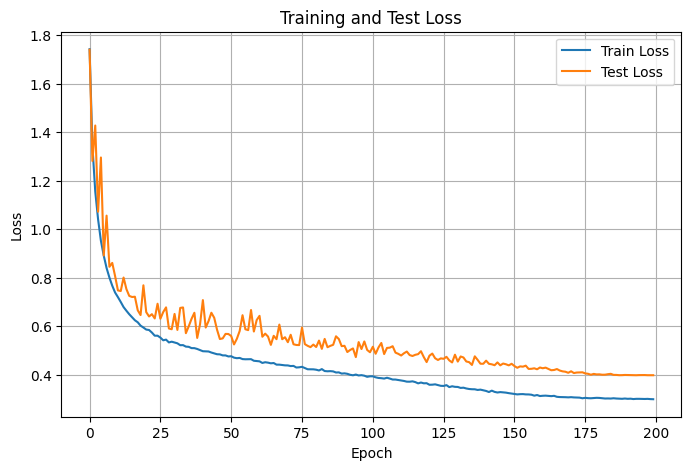

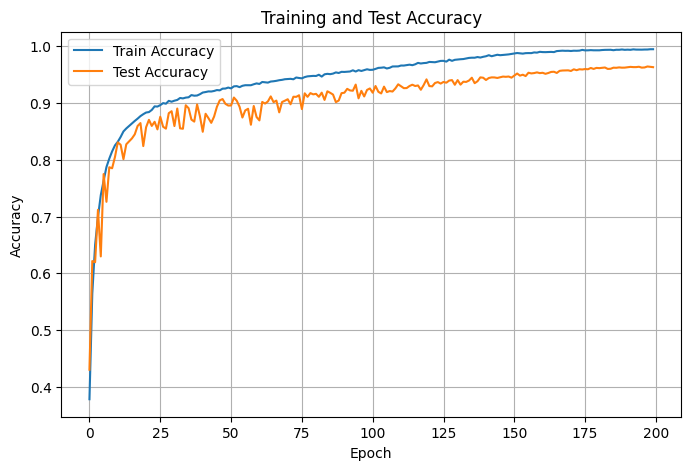

In [ ]:
print(f"Best test acc: {best_test_acc:.4f}")
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()
# 0.9643

In [ ]:
def evaluate_tta(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device).long()

            logits1 = model(x)

            x_flip = torch.flip(x, dims=[3])
            logits2 = model(x_flip)

            logits = (logits1 + logits2) / 2

            loss = criterion(logits, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size

            preds = logits.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples

model.load_state_dict(torch.load("cifar-10.pt"))
tta_loss, tta_acc = evaluate_tta(model, test_loader, criterion, device)

print("TTA acc:", tta_acc)

TTA acc: 0.9645
